## Análisis exploratorio de datos

In [21]:
import numpy as np 
import os

# Indicamos la ruta a los datos
PATH = "../Data/processed"

# Cargamos los datos
# Contienen etiquetas con los puntos clave del cuerpo durante las flexiones
# Los arrays tienen forma (num_ejemplos, num_frames, num_keypoints)
# num_keypoints -> 1er_punto_clave_x, 1er_punto_clave_y, 2º_punto_clave_x, 2º_punto_clave_y, ...

correct_push_ups = np.load(os.path.join(PATH, 'mirrored_correct_push_ups_landmarks.npy'))
wrong_push_ups = np.load(os.path.join(PATH, 'mirrored_wrong_push_ups_landmarks.npy'))

print("Correct push-ups shape:", correct_push_ups.shape)
print("Incorrect push-ups shape:", wrong_push_ups.shape)

Correct push-ups shape: (50, 160, 66)
Incorrect push-ups shape: (50, 160, 66)


Vemos que ambos conjuntos de datos tienen el mismo número de videos, cada vídeo tiene el mismo número de frames y cada frame tiene el mismo número de landmarks.

**¿Cuál es el rango de valores que toman las coordenadas?**

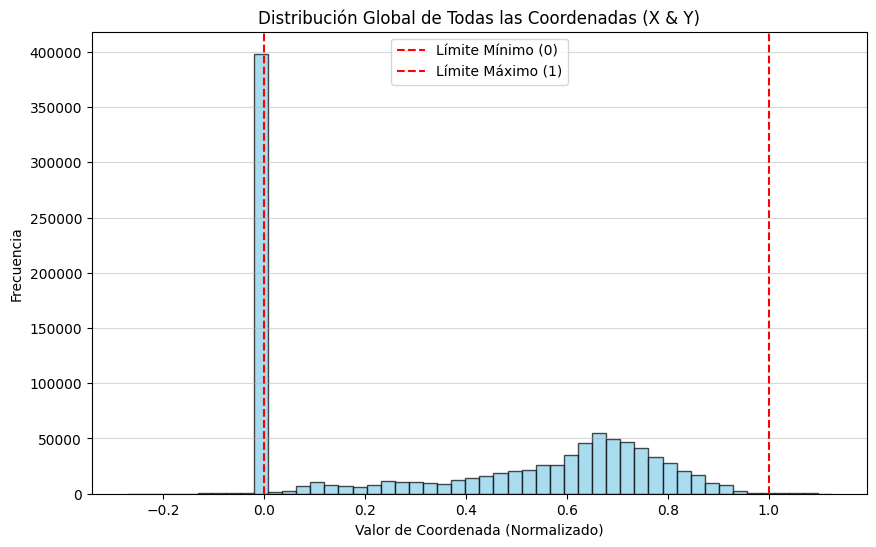

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Asumiendo que 'data_array' es un numpy array de forma (50, 160, 66)
# data_array = np.load('tu_archivo.npy') 

# 1. Aplana todos los datos de coordenadas
all_coords = np.concatenate((correct_push_ups, wrong_push_ups)).flatten()

# 2. Configura y graficar el histograma
plt.figure(figsize=(10, 6))
plt.hist(all_coords, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribución Global de Todas las Coordenadas (X & Y)')
plt.xlabel('Valor de Coordenada (Normalizado)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', label='Límite Mínimo (0)')
plt.axvline(x=1, color='r', linestyle='--', label='Límite Máximo (1)')
plt.legend()
plt.show()

La herramienta de visión artificial MediaPipe Pose predice la posición de 33 puntos clave del cuerpo (x, y), tomando como origen la esquina inferior izquierda del frame. Cada vídeo tenía una longitud distinta originalmente. Sin embargo, anteriormente añadimos paddings de 0s para que todas las secuencias tuvieran la misma longitud, lo que explica la gran cantidad de ceros observada en el histograma. En la arquitectura de red indicaremos que estos 0s son de padding con una capa Masking.

Por otro lado, algunos valores de las coordenadas superan 1 o son menores a 0. Esto ocurre cuando ciertos puntos clave quedan fuera del plano de la imagen. Estos datos pueden considerarse válidos, ya que únicamente representan posiciones fuera del marco visual y, siempre que mantengan coherencia geográfica con el resto del cuerpo, no deberían afectar negativamente al modelo de clasificación.




**¿Cuál es la proporción de relleno (padding) en cada vídeo?**

Veámos la distribución de esta medida en el dataset.

In [23]:
video0 = correct_push_ups[0]  # primer vídeo
#print(video0.shape)  # (160, 66)
#print(video0)        # imprime todos los frames y landmarks del vídeo 0, cada fila indica los landmarks de un frame 

frame0_video0 = correct_push_ups[0, 0]  # primer frame del primer vídeo
#print(frame0_video0.shape)  # (66,)
#print(frame0_video0)        # imprime los 66 landmarks de ese frame (coincide con la primera fila del print anterior)

landmark0_frame0_video0 = correct_push_ups[0, 0, 0]  # primer landmark
#print(landmark0_frame0_video0)  # valor del landmark 

Media de padding por secuencia: 37.62%
Máximo padding: 71.88%
Mínimo padding: 0.00%


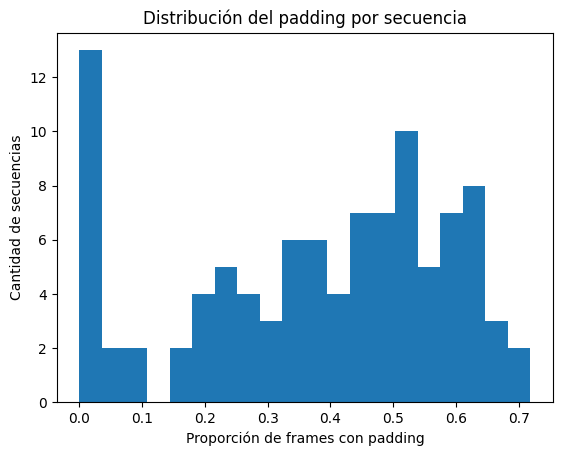

In [24]:
# Calculamos la proporción de frames vacíos (rellenos con ceros) por secuencia
padding_ratios = []

data = np.vstack((correct_push_ups, wrong_push_ups))
for seq in data:
    # Un frame está vacío si todos sus landmarks son 0 
    empty_frames = np.sum(np.all(seq == 0, axis=1)) # suma cada fila que es todo 0
    ratio = empty_frames / seq.shape[0]
    padding_ratios.append(ratio)

# Estadísticas del padding
print(f"Media de padding por secuencia: {np.mean(padding_ratios):.2%}")
print(f"Máximo padding: {np.max(padding_ratios):.2%}")
print(f"Mínimo padding: {np.min(padding_ratios):.2%}")

# Distribución visual
plt.hist(padding_ratios, bins=20)
plt.xlabel("Proporción de frames con padding")
plt.ylabel("Cantidad de secuencias")
plt.title("Distribución del padding por secuencia")
plt.show()

El porcentaje obtenido es un poco alto, 37.63% pero esto se debe a que en los videos incorrectos, algunos (9 videos) superaban los 200 frames, llegando hasta los 400, por lo que esto incrementó el numero óptimo de frames por vídeo al calcular $L_{opt}$.

Vamos a comprobar si los landmarks están normalizados

In [25]:
longitudes_combinadas = np.vstack((correct_push_ups, wrong_push_ups)).reshape(-1, correct_push_ups.shape[2]) 
# Con el -1 del reshape combinamos el número de videos y el número de frames, obteniendo una lista donde cada fila es un frame individual de cualquier video (100*160 numero de filas).
# 'correct_push_ups.shape[2]' lo que hace es mantener el número de landmarks (66) como el número de columnas, es decir, cada fila tiene los 66 landmarks de ese frame.

min_val = np.min(longitudes_combinadas)
max_val = np.max(longitudes_combinadas)

print(f"Valor mínimo de coordenadas: {min_val:.4f}")
print(f"Valor máximo de coordenadas: {max_val:.4f}")

Valor mínimo de coordenadas: -0.2720
Valor máximo de coordenadas: 1.1252


Vamos a normalizar los landmarks.

In [26]:
rango = max_val - min_val

# Aplicamos la fórmula de Re-normalización
longitudes_combinadas_escaladas = (longitudes_combinadas - min_val) / rango

correct_push_ups_escaladas = (correct_push_ups - min_val) / rango
incorrect_push_ups_escaladas = (wrong_push_ups - min_val) / rango

In [27]:
correct_push_ups_escaladas = correct_push_ups
incorrect_push_ups_escaladas = wrong_push_ups

Podemos ver que en el caso de los vídeos correctos (los únicos que hemos seleccionado), los landmarks se agrupan por zonas más o menos diferenciadas, lo cual es indicativo de que los landmarks están ordenados. Es un poco complicado diferenciar las partes del cuerpo, por lo que vamos a ver la distribución espacial de los landmarks uniendo los puntos para poder visualizar la pose promedio de cada clase.

In [28]:
# Definimos las conexiones del esqueleto (pares de índices de landmarks) 
# Esto es específico para un modelo de 33 landmarks (como MediaPipe Pose), cada tupla (start_idx, end_idx) conecta dos landmarks.
# Si buscamos información sobre las conexiones de MediaPipe Pose: https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker?hl=es-419#models, vemos que cada punto corresponde a la siguiente parte del cuerpo:
CONNECTIONS = [
    # Cabeza
    (0, 1), (1, 2), (2, 3), (3, 7), 
    (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10), 

    # Torso y Hombros
    (11, 12),  # Hombros
    (11, 23),  # Hombro Izquierdo a Cadera Izquierda
    (12, 24),  # Hombro Derecho a Cadera Derecha
    (23, 24),  # Caderas

    # Brazo Izquierdo
    (11, 13), (13, 15), 
    # Mano Izquierda
    (15, 17), (15, 19), (15, 21), 

    # Brazo Derecho
    (12, 14), (14, 16), 
    # Mano Derecha
    (16, 18), (16, 20), (16, 22), 

    # Pierna Izquierda
    (23, 25), (25, 27), 
    # Pie Izquierdo
    (27, 29), (29, 31), 

    # Pierna Derecha
    (24, 26), (26, 28), 
    # Pie Derecho
    (28, 30), (30, 32) 
]

def plot_pose_media(data_correctas, data_incorrectas, title="Comparación de Pose Media"):
    """
    data_correctas: array (N, F, dims)
    data_incorrectas: array (N, F, dims)
    dims = 66 (x,y), 99 (x,y,z), 132 (x,y,z,visibility)
    
    Dibuja el esqueleto promedio para ambas clases.
    """
    
    def compute_pose_media(dataset):
        frames = dataset.reshape(-1, dataset.shape[-1])  # Aplanamos (n_videos*frames, 66)
        dims_per_point = frames.shape[-1] // 33 # Calculamos cuántas dimensiones tiene cada punto (x,y) o (x,y,z). En nuestro caso 66valores/33landmarks=2dimensiones (x,y) por landmark
        mean_pose = np.mean(frames, axis=0) # Calculamos el promedio de cada columna a lo largo de todos los frames. Esto genera un vector con (33 * dims_per_point) valores
        return mean_pose.reshape(33, dims_per_point)[:, :2] # Reorganizamos ese vector en forma de (33 puntos, dims_per_point) -> Solo x,y
    
    pose_correcta = compute_pose_media(data_correctas)
    pose_incorrecta = compute_pose_media(data_incorrectas)
    
    # ---- GRÁFICO ----
    plt.figure(figsize=(8, 8))
    plt.title(title)
    plt.xlabel("X normalizada")
    plt.ylabel("Y normalizada")
    plt.gca().invert_yaxis()

    # Puntos
    plt.scatter(pose_correcta[:, 0], pose_correcta[:, 1],
                color="blue", label="Correcta", s=80, alpha=0.8)
    plt.scatter(pose_incorrecta[:, 0], pose_incorrecta[:, 1],
                color="red", label="Incorrecta", s=80, alpha=0.8)

    # Conexiones
    for a, b in CONNECTIONS:
        x1, y1 = pose_correcta[a]
        x2, y2 = pose_correcta[b]
        plt.plot([x1, x2], [y1, y2],
                 color="blue", alpha=0.6, linewidth=2)

        x1, y1 = pose_incorrecta[a]
        x2, y2 = pose_incorrecta[b]
        plt.plot([x1, x2], [y1, y2],
                 color="red", alpha=0.6, linewidth=2, linestyle="--")

    plt.legend()
    plt.grid(True)
    plt.show()

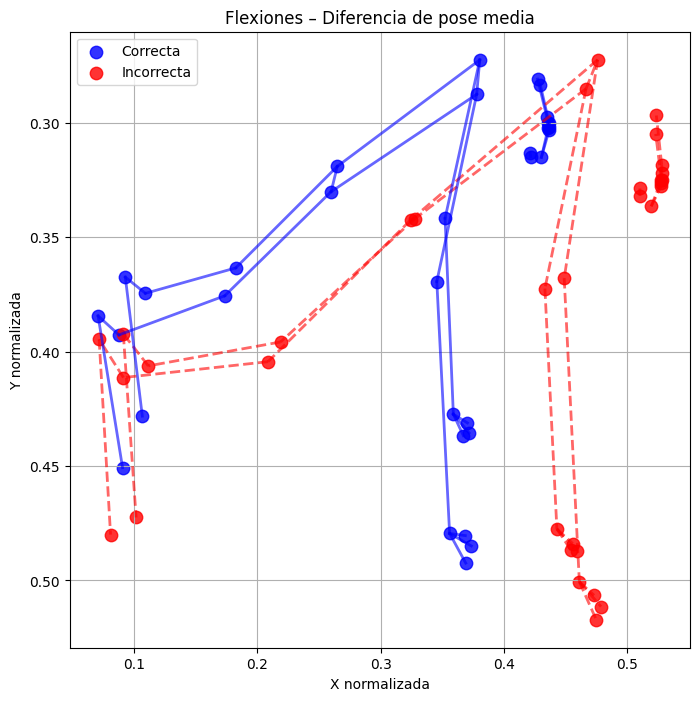

In [29]:
plot_pose_media(correct_push_ups_escaladas,
                incorrect_push_ups_escaladas,
                title="Flexiones – Diferencia de pose media")

Se aprecian perfectamente las partes del cuerpo en ambas clases y se ve cómo en la clase de flexiones incorrectas, las rodillas y la cabeza están más abajo de lo normal.


### Estadísticas descriptivas

Media, desviación estándar y rango por landmark (x, y).

Comparación entre clases: ¿la media de la posición del pecho o codo difiere entre clases?

In [30]:
# Definimos los nombres de los landmarks 
LANDMARK_NAMES = [
    'nose', 'left eye (inner)', 'left eye', 'left eye (outer)', 'right eye (inner)', 'right eye', 'right eye (outer)', 
    'left ear', 'right ear', 'mouth (left)', 'mouth (right)', 'left shoulder', 'right shoulder', 'left elbow', 
    'right elbow', 'left wrist', 'right wrist', 'left pinky', 'right pinky', 'left index', 'right index', 
    'left thumb', 'right thumb', 'left hip', 'right hip', 'left knee', 'right knee', 'left ankle', 
    'right ankle', 'left heel', 'right heel', 'left foot index', 'right foot index'
]

def compute_landmark_statistics(dataset, label=None):
    """
    dataset: array (N_videos, N_frames, dims)
    dims = 33*2, 33*3, o 33*4

    Returns DataFrame con estadísticas descriptivas de cada coordenada.
    """

    n_points = 33
    dims_per_point = dataset.shape[-1] // n_points

    # Generamos nombres de coordenadas dinámicamente
    coord_letters = ["X", "Y", "Z", "visibility"][:dims_per_point]
    coord_names = [f"{lm} ({c})" for lm in LANDMARK_NAMES for c in coord_letters]

    # Aplanamos los datos para que cada fila sea un frame único. (N_total_frames, dims)
    frames = dataset.reshape(-1, dataset.shape[-1]) 

    # Calculamos las estadísticas a lo largo del eje 0 (todos los frames)
    stats = {
        "Coordenada": coord_names,
        "Media (μ)": np.mean(frames, axis=0),
        "Desviación Estándar (σ)": np.std(frames, axis=0),
        "Máximo": np.max(frames, axis=0),
        "Mínimo": np.min(frames, axis=0)
    }
    stats["Rango (Max - Min)"] = stats["Máximo"] - stats["Mínimo"]

    df = pd.DataFrame(stats)

    if label is not None: 
        df.insert(0, "Clase", label)

    return df

In [31]:
import pandas as pd 
NUM_COORDS = correct_push_ups_escaladas.shape[2]  # 66 (33 puntos * 2 coordenadas)
# Análisis de la clase Correcta
df_correctas = compute_landmark_statistics(correct_push_ups_escaladas, label='Correcta')

# Análisis de la clase Incorrecta
df_incorrectas = compute_landmark_statistics(incorrect_push_ups_escaladas, label='Incorrecta')

# Análisis del conjunto combinado (para variabilidad global)
longitudes_combinadas_escaladas = np.vstack((correct_push_ups_escaladas.reshape(-1, NUM_COORDS), 
                                            incorrect_push_ups_escaladas.reshape(-1, NUM_COORDS)))

df_combinado = compute_landmark_statistics(longitudes_combinadas_escaladas, label='Global')

# Podemos usar pandas.concat para ver todas las estadísticas juntas
df_final = pd.concat([df_correctas, df_incorrectas, df_combinado], ignore_index=True)
print(df_final.to_markdown(index=False)) # Hacemos que la tabla se vea bien en la terminal

| Clase      | Coordenada            |   Media (μ) |   Desviación Estándar (σ) |   Máximo |    Mínimo |   Rango (Max - Min) |
|:-----------|:----------------------|------------:|--------------------------:|---------:|----------:|--------------------:|
| Correcta   | nose (X)              |   0.430248  |                 0.382033  | 0.934721 |  0        |            0.934721 |
| Correcta   | nose (Y)              |   0.315182  |                 0.301273  | 0.91551  |  0        |            0.91551  |
| Correcta   | left eye (inner) (X)  |   0.435823  |                 0.38682   | 0.942576 |  0        |            0.942576 |
| Correcta   | left eye (inner) (Y)  |   0.3022    |                 0.29212   | 0.906523 |  0        |            0.906523 |
| Correcta   | left eye (X)          |   0.435307  |                 0.38638   | 0.941406 |  0        |            0.941406 |
| Correcta   | left eye (Y)          |   0.300007  |                 0.290472  | 0.903217 |  0        |            0.9

Con estos resultados podemos ver la ubicación media de diversas partes del cuerpo, por ejemplo la nariz está a una altura de 0.533876 del eje X, mientras que el pie derecho está a una altura de 0.268688 respecto al eje X. Las desviaciones nos sirven para ver cuanto varía la posición del landmark respecto a su media, y como podemos observar, obtenemos valores normales teniendo en cuenta que el movimiento es una flexión. Si nos vamos a partes más fijas a lo largo de una flexión, como pueden ser los pies que permanecen inmóviles, obtenemos desviaciones mucho más bajas en el eje X, como 0.0780976 en el pie izquierdo y 0.0738948 en el derecho.

### Ángulos que forman los landmarks
Unas características muy importantes a la hora de determinar si una flexión se realiza correctamente son los ángulos articulares (por ejemplo, doblar las rodillas es síntoma de que la técnica no es buena).

In [32]:
KEYPOINTS = {
    'nariz': 0,
    'hombro_I': 11, 'hombro_D': 12,
    'codo_I': 13,   'codo_D': 14,
    'muñeca_I': 15, 'muñeca_D': 16,
    'cadera_I': 23, 'cadera_D': 24,
    'rodilla_I': 25, 'rodilla_D': 26,
    'tobillo_I': 27, 'tobillo_D': 28
}

def get_coords(landmarks, idx):
    """
    Devuelve las coordenadas del landmark idx.
    Funciona con landmarks en formato:
       2D → [x,y]
       3D → [x,y,z]
       4D → [x,y,z,visibility]
    """
    dims = landmarks.shape[-1] // 33
    start = idx * dims
    end = start + dims
    return landmarks[start:end]

def calculate_angle(p1, p2_vertex, p3):
    """
    Calcula el ángulo en B dado A-B-C.
    Robusto frente:
    - vectores cero
    - NaNs
    - rango del coseno
    """

    if np.any(np.isnan([p1, p2_vertex, p3])):
        return 0.0
    
    # Calculamos los vectores
    vector_ba = p1 - p2_vertex
    vector_bc = p3 - p2_vertex

    norm_ba = np.linalg.norm(vector_ba)
    norm_bc = np.linalg.norm(vector_bc)

    # Manejamos el caso de vectores de longitud cero
    if norm_ba < 1e-6 or norm_bc < 1e-6:
        return 0.0

    # Calculamos el coseno del ángulo usando la fórmula del producto punto. 
    cos_theta = np.dot(vector_ba, vector_bc) / (norm_ba * norm_bc + 1e-6) # Se añade 1e-6 para evitar división por cero en caso de vectores muy pequeños
    
    # Nos aseguramos que el valor esté en el rango [-1, 1] para evitar errores numéricos al pasar cos_theta a arccos
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    return np.degrees(np.arccos(cos_theta))

def get_key_joint_angles(frame):
    """
    frame: vector 1D con landmarks (66, 99 o 132 valores)
    
    Devuelve un dict con los ángulos claves.
    """
    angles = {}

    # Para abreviar
    get = lambda name: get_coords(frame, KEYPOINTS[name])

    # Ángulos de codo
    angles['codo_I'] = calculate_angle(get('hombro_I'), get('codo_I'), get('muñeca_I'))
    angles['codo_D'] = calculate_angle(get('hombro_D'), get('codo_D'), get('muñeca_D'))

    # Alineación del tronco
    angles['cadera_I_tronco'] = calculate_angle(get('hombro_I'), get('cadera_I'), get('rodilla_I'))
    angles['cadera_D_tronco'] = calculate_angle(get('hombro_D'), get('cadera_D'), get('rodilla_D'))

    # Rodillas (sentadillas)
    angles['rodilla_I'] = calculate_angle(get('cadera_I'), get('rodilla_I'), get('tobillo_I'))
    angles['rodilla_D'] = calculate_angle(get('cadera_D'), get('rodilla_D'), get('tobillo_D'))

    # Cadera (sentadillas) – reutilizamos el cálculo
    angles['cadera_I_squat'] = angles['cadera_I_tronco']
    angles['cadera_D_squat'] = angles['cadera_D_tronco']

    # Tronco usando la nariz
    angles['tronco_nariz_I'] = calculate_angle(get('nariz'), get('hombro_I'), get('cadera_I'))
    angles['tronco_nariz_D'] = calculate_angle(get('nariz'), get('hombro_D'), get('cadera_D'))

    return angles

def landmarks_to_angle_df(dataset, add_video_id=False):
    """
    dataset: array con forma (n_videos, n_frames, dims)
    dims = 66, 99 o 132 según tengas 33*2, 33*3, 33*4 valores.

    Devuelve:
        DataFrame con 8 columnas de ángulos.
        (optional) columnas video_id y frame_id.
    """

    n_videos, n_frames, dims = dataset.shape

    rows = []

    # Recorremos todos los vídeos y frames
    for video_idx in range(n_videos):
        for frame_idx in range(n_frames):

            # Extraemos el vector de landmarks 1D para el frame actual.
            frame = dataset[video_idx, frame_idx]

            # Si la suma de todas las coordenadas es cero, se asume que es un frame de 'padding' (relleno) y se omite
            if frame.sum() == 0:
                continue

            # Llamamos a la función ya definida para calcular los ángulos clave
            angles = get_key_joint_angles(frame)

            # Añadimos IDs si se solicita. Por trazabilidad.
            if add_video_id:
                angles['video_id'] = video_idx
                angles['frame_id'] = frame_idx

            # Añadimos el diccionario de ángulos (e indices) a la lista de filas
            rows.append(angles)

    # Convertimos la lista de diccionarios (rows) en un DataFrame de Pandas donde cada diccionario se convierte en una fila.
    return pd.DataFrame(rows)

In [33]:
# Vamos a almacenar en discos los arrays con los ángulos articulares de cada frame en todos los vídeos
def calcular_angulos_esqueleto(landmarks):
    """
    landmarks: array 1D con forma (66,)

    Devuelve un array 1D con los ángulos clave del esqueleto.
    """

    angles_dict = get_key_joint_angles(landmarks)
    return np.array(list(angles_dict.values()))

angulos_procesados_correct_pu = np.apply_along_axis(
    func1d=calcular_angulos_esqueleto, 
    axis=2, #-1
    arr=correct_push_ups
)

angulos_procesados_wrong_pu = np.apply_along_axis(
    func1d=calcular_angulos_esqueleto, 
    axis=2, #-1
    arr=wrong_push_ups
)

# Almacenamos en discos los arrays con los ángulos articulares procesados
#np.save("../data/processed/correct_push_ups_angles.npy", angulos_procesados_correct_pu)
#np.save("../data/processed/wrong_push_ups_angles.npy",   angulos_procesados_wrong_pu)

In [34]:
# Almacenamos en discos los arrays con los ángulos articulares procesados
np.save("../data/processed/mirrored_correct_push_ups_angles.npy", angulos_procesados_correct_pu) # datos con angulos sobre flexiones correctas (videos normales y mirror correctos)
np.save("../data/processed/mirrored_wrong_push_ups_angles.npy",   angulos_procesados_wrong_pu) # datos con angulos sobre flexiones incorrectas (videos normales y mirror incorrectos)

In [35]:
np.array(list(get_key_joint_angles(seq[0]).values()))

array([175.5317317 , 179.20867468, 159.11045516, 163.15346079,
       167.53371207, 168.01234501, 159.11045516, 163.15346079,
       128.03746233,  79.35861405])

In [36]:
angles_correct = landmarks_to_angle_df(correct_push_ups_escaladas, add_video_id=True)
angles_wrong = landmarks_to_angle_df(incorrect_push_ups_escaladas, add_video_id=True)

In [37]:
# Añadimos etiquetas
angles_correct["Clase"] = "Correcto"
angles_wrong["Clase"] = "Incorrecto"

# Unimos las dos tablas
df_combined = pd.concat([angles_correct, angles_wrong], ignore_index=True)

In [38]:
print(df_combined.shape) # tiene 9979 filas y no 16000 (100*160) porque se han eliminado los frames vacíos
df_combined.head()

(9980, 13)


,codo_I,codo_D,cadera_I_tronco,cadera_D_tronco,rodilla_I,rodilla_D,cadera_I_squat,cadera_D_squat,tronco_nariz_I,tronco_nariz_D,video_id,frame_id,Clase
0,174.656106,168.874954,165.050149,167.179704,171.605439,177.590275,165.050149,167.179704,130.789457,136.703694,0,0,Correcto
1,174.669044,168.952488,165.393428,167.523088,173.190720,177.493025,165.393428,167.523088,130.807664,134.889537,0,1,Correcto
2,174.790783,169.672831,165.428558,167.751820,173.715543,177.522200,165.428558,167.751820,130.525081,135.134816,0,2,Correcto
3,175.857178,171.147028,164.916760,167.398818,173.868338,177.058404,164.916760,167.398818,132.821773,139.689551,0,3,Correcto
4,176.580444,172.149426,164.902520,166.982518,174.104588,176.875145,164.902520,166.982518,133.186171,140.996203,0,4,Correcto


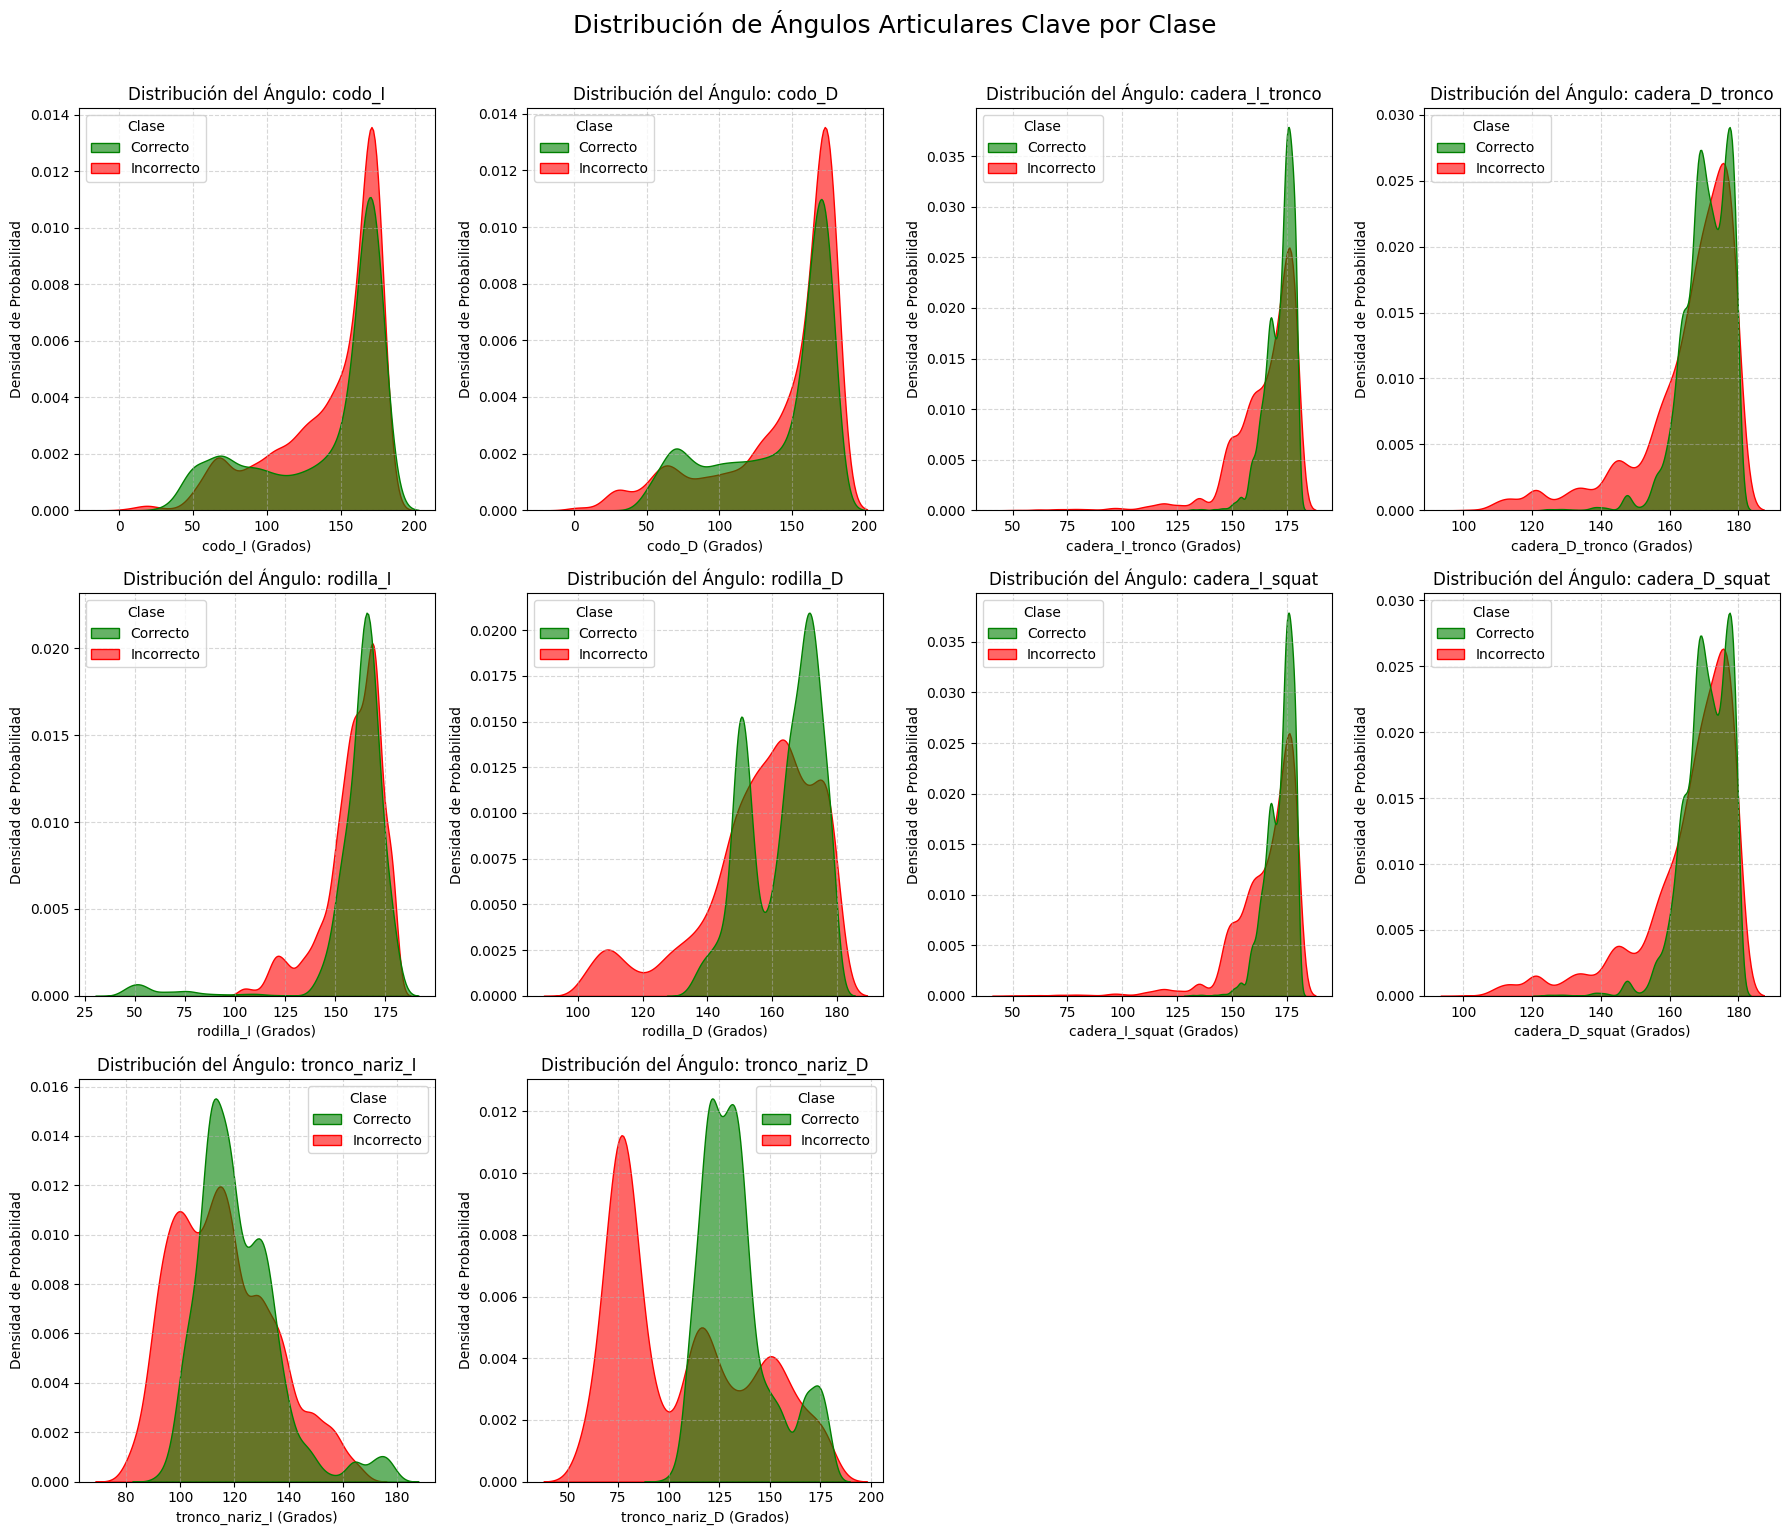

In [39]:
import seaborn as sns
# Definimos las columnas de ángulos a graficar excluyendo las columnas que no son ángulos ('Clase', 'video_id', 'frame_id')
columns_to_exclude = ['Clase', 'video_id', 'frame_id']
all_angle_columns = [col for col in df_combined.columns if col not in columns_to_exclude]
num_plots = len(all_angle_columns)

# Configuramos el lienzo 
cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    nrows=rows, 
    ncols=min(num_plots, cols), 
    figsize=(18, 5 * rows)
)
# Aplanamos los ejes para facilitar el indexado
axes = axes.flatten() 

# Título general
fig.suptitle('Distribución de Ángulos Articulares Clave por Clase', 
             fontsize=18, 
             y=1.02)

# Bucle para generar los gráficos de densidad KDE
for i, angle_col in enumerate(all_angle_columns):
    
    # usamos seaborn.kdeplot para comparar las distribuciones 
    sns.kdeplot(
        data=df_combined,
        x=angle_col,
        hue='Clase', # Diferencia las clases por color
        fill=True, # Rellena el área bajo la curva
        palette={'Correcto': 'green', 'Incorrecto': 'red'},
        alpha=0.6,
        ax=axes[i]
    )
    
    # Configuración de los ejes y el título
    axes[i].set_title(f'Distribución del Ángulo: {angle_col}')
    axes[i].set_xlabel(f'{angle_col} (Grados)')
    axes[i].set_ylabel('Densidad de Probabilidad')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Limpiamos subplots vacíos (solo tenemos 10 gráficos y el grid es de 12)
for empty_idx in range(num_plots, rows * cols):
    if empty_idx < len(axes): # Pequeña comprobación
        fig.delaxes(axes[empty_idx])

# Ajustamos diseño y mostramos
plt.tight_layout(rect=[0, 0, 1, 1.01])
plt.show()

Parece que las distribuciones de los ángulos articulares de cada clase son muy similares. Si nos fijamos en las distribuciones de los ángulos de las rodillas, por debajo de 150º encontramos más frames de posturas incorrectas que correctas (cuanto menor sea el ángulo más se dobla la articulación).

### Reducción de dimensionalidad

Aplicamos PCA o t-SNE sobre los vectores medios de cada vídeo → ver si las clases se separan visualmente.

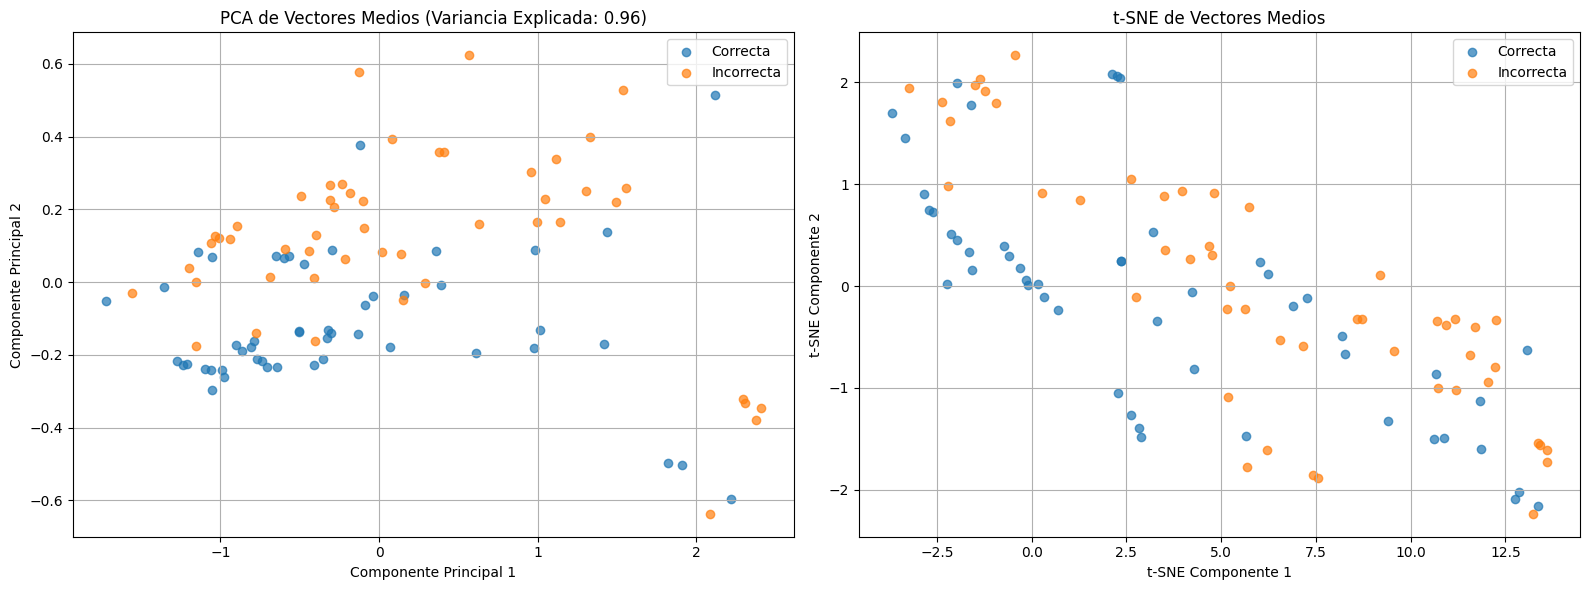

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Calculamos el vector medio (pose promedio) por vídeo 
mean_vectors_correct = np.mean(correct_push_ups_escaladas, axis=1) # Media a lo largo del eje 1 (frames). Esto reduce la forma (Videos, Frames, Coordenadas) a (Videos, Coordenadas)
mean_vectors_incorrect = np.mean(incorrect_push_ups_escaladas, axis=1)

# Combinamos los vectores medios en una sola matriz (X_mean) y creamos etiquetas (y)
X_mean = np.vstack((mean_vectors_correct, mean_vectors_incorrect))
y = np.array(['Correcta'] * mean_vectors_correct.shape[0] + ['Incorrecta'] * mean_vectors_incorrect.shape[0])

# Aplicamos PCA 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_mean)
explained_variance = pca.explained_variance_ratio_.sum()

# Aplicamos t-SNE 
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto') 
X_tsne = tsne.fit_transform(X_mean)

# Generamos gráficos
plt.figure(figsize=(16, 6))

# Subplot 1: PCA
plt.subplot(1, 2, 1)
for label in np.unique(y):
    subset = X_pca[y == label]
    plt.scatter(subset[:, 0], subset[:, 1], label=label, alpha=0.7)

plt.title(f'PCA de Vectores Medios (Variancia Explicada: {explained_variance:.2f})')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)

# Subplot 2: t-SNE
plt.subplot(1, 2, 2)
for label in np.unique(y):
    subset = X_tsne[y == label]
    plt.scatter(subset[:, 0], subset[:, 1], label=label, alpha=0.7)

plt.title('t-SNE de Vectores Medios')
plt.xlabel('t-SNE Componente 1')
plt.ylabel('t-SNE Componente 2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('visualizacion_separacion_clases.png')
plt.show()

En el PCA, a pesar de que ambos conjuntos no estén completamente separados (se mezclan en el centro) podemos ver cómo los puntos naranjas (flexiones incorrectas) se agrupan en la parte superior derecha (valores más altos), mientras que los puntos que hacen referencia a las flexiones bien hechas, se agrupan en la parte media-inferior izquierda (valores más bajos) 

El gráfico de t-SNE confirma la separación encontrada por PCA. t-SNE muestra una clara estructura lineal donde los puntos de una clase siguen una línea que está por encima o por debajo de los puntos de la otra clase, con una separación mínima. La mayoría de los puntos incorrectos (naranja) están desplazados ligeramente por encima y a la izquierda de los puntos correctos (azul). Esto sugiere que la diferencia entre las clases es ciertamente consistente.  
Concluyendo, mediante t-SNE observamos que en el espacio de alta dimensión (los 66 landmarks), los videos de una clase están íntimamente relacionados entre sí, y que la distancia entre un video correcto y un video incorrecto es grande.